### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

### Train Val Split

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=876567
)

train_idx, val_idx = next(sgkf.split(df, df['dx'], df['lesion_id']))
df['split'] = 'train'
df.loc[val_idx, 'split'] = 'val'

# sanity checks
# 1 - Ensure ZERO data leakage across lesion_ids
train_lesions = set(df[df['split'] == 'train']['lesion_id'])
val_lesions = set(df[df['split'] == 'val']['lesion_id'])
overlapping_lesions = train_lesions.intersection(val_lesions)
print(f"Overlapping lesion_ids between Train and Val: {len(overlapping_lesions)}")
assert len(overlapping_lesions) == 0, "Data Leakage Detected!"

# 2 - Check overall split ratio
print("\n--- Split Ratio ---")
print(df['split'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# 3 - Check class distribution (Stratification check)
print("\n--- Class Distribution by Split (%) ---")
dist_check = pd.crosstab(df['dx'], df['split'], normalize='columns').mul(100).round(2)
print(dist_check)

output_filename = 'HAM10000_metadata_split_80_20.csv'
df.to_csv(output_filename, index=False)
print(f"\nSuccessfully saved fixed split to: {output_filename}")

Overlapping lesion_ids between Train and Val: 0

--- Split Ratio ---
split
train    80.21%
val      19.79%
Name: proportion, dtype: object

--- Class Distribution by Split (%) ---
split  train    val
dx                 
akiec   3.17   3.63
bcc     5.13   5.15
bkl    11.28   9.74
df      1.10   1.36
mel    11.08  11.25
nv     66.80  67.56
vasc    1.44   1.31

Successfully saved fixed split to: HAM10000_metadata_split_80_20.csv


In [3]:
split = pd.read_csv('/kaggle/working/HAM10000_metadata_split_80_20.csv')

train_df = split[split['split'] == 'train']
val_df = split[split['split'] == "val"]

print(train_df.shape)
print(val_df.shape)

(8033, 8)
(1982, 8)


### Caching

In [4]:
IMG_SIZE = 380
img_dirs = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]

label_map = {label : idx for idx, label in enumerate(sorted(split['dx'].unique()))}

path_map = {}
for d in img_dirs:
    for fname in os.listdir(d):
        if fname.endswith(".jpg"):
            image_id = fname[:-4]
            path_map[image_id] = os.path.join(d, fname)

resize_only = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

def build_cache(df, path_map, save_path):
    images = torch.zeros((len(df), 3, 380, 380), dtype=torch.float32)
    for i, row in df.reset_index(drop=True).iterrows():
        img = Image.open(path_map[row['image_id']]).convert('RGB')
        images[i] = resize_only(img)
        if i % 1000 == 0:
            print(f"{i}/{len(df)}")
    torch.save(images, save_path)
    print(f"Saved cache to {save_path}")

# build once, reuse across all 20 epochs
build_cache(train_df, path_map, '/kaggle/working/train_cache.pt')
build_cache(val_df, path_map, '/kaggle/working/val_cache.pt')

0/8033
1000/8033
2000/8033
3000/8033
4000/8033
5000/8033
6000/8033
7000/8033
8000/8033
Saved cache to /kaggle/working/train_cache.pt
0/1982
1000/1982
Saved cache to /kaggle/working/val_cache.pt


In [5]:
class_names = sorted(label_map, key=label_map.get)

print(class_names)
print(label_map)
# class_names[i] should correspond to index i in label_map.values()

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


### Dataset / DataLoader

In [6]:
class CachedHAMDataset(Dataset):
    def __init__(self, cache_path, df, label_map):
        self.images = torch.load(cache_path)
        self.labels = [label_map[l] for l in df['dx']]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx] # just indexing, nothing else


train_cache_path = "/kaggle/working/train_cache.pt"
val_cache_path = "/kaggle/working/val_cache.pt"

train_dataset = CachedHAMDataset(train_cache_path, train_df, label_map)
val_dataset = CachedHAMDataset(val_cache_path, val_df, label_map)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True      # faster CPU->GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

### Training

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha # tensor of per-class weights, or None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

model = timm.create_model("efficientnet_b4", pretrained=True, num_classes=7)
model = model.to(device)

# alpha calculation
class_counts = train_df['dx'].value_counts().reindex(class_names)
alpha = (1.0 / class_counts)
alpha = alpha / alpha.sum() * len(class_names)
alpha = torch.tensor(alpha.values, dtype=torch.float32).to(device)

alpha = torch.clamp(alpha, max=alpha.median() * 3)  # cap outliers

criterion = FocalLoss(alpha=alpha, gamma=1.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        images = (images - MEAN) / STD
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device)
            images = (images - MEAN) / STD
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / total, correct / total, macro_f1

In [15]:
print("class_names:", class_names)
print("label_map:", label_map)
print("class_counts (train, in label_map order):", class_counts)
print("alpha:", alpha)

class_names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
label_map: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
class_counts (train, in label_map order): dx
akiec     255
bcc       412
bkl       906
df         88
mel       890
nv       5366
vasc      116
Name: count, dtype: int64
alpha: tensor([0.9549, 0.5910, 0.2688, 1.7731, 0.2736, 0.0454, 1.7731],
       device='cuda:0')


In [16]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': []
}

best_f1 = 0.0
NUM_EPOCHS = 20
CHECKPOINT_PATH = 'best_model_focal.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
        }, CHECKPOINT_PATH)
        print(f"  → New best model saved (F1: {val_f1:.4f})")

print(f"\nTraining complete. Best Val F1: {best_f1:.4f}")

  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 0.1647 Acc: 0.1599 | Val Loss: 0.1401 Acc: 0.2361 F1: 0.2316
  → New best model saved (F1: 0.2316)


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: 0.0572 Acc: 0.4249 | Val Loss: 0.1211 Acc: 0.4591 F1: 0.3720
  → New best model saved (F1: 0.3720)


  0%|          | 0/251 [00:00<?, ?it/s]

...

Epoch 18/20 | Train Loss: 0.0005 Acc: 0.9609 | Val Loss: 0.2244 Acc: 0.7830 F1: 0.6087


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.0009 Acc: 0.9503 | Val Loss: 0.2050 Acc: 0.7815 F1: 0.5907


  0%|          | 0/251 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.0013 Acc: 0.9508 | Val Loss: 0.2010 Acc: 0.7659 F1: 0.5952

Training complete. Best Val F1: 0.6189


### Plots

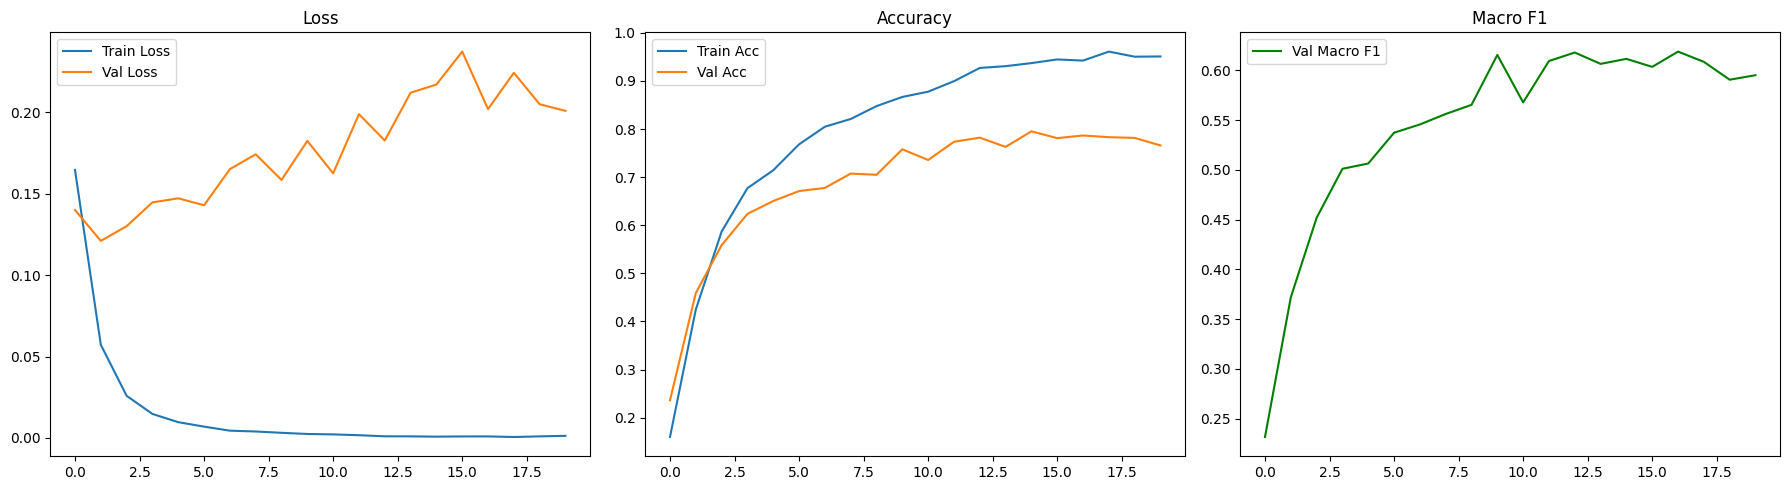

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(history['val_f1'], label='Val Macro F1', color='green')
axes[2].set_title('Macro F1'); axes[2].legend()

plt.tight_layout()
plt.show()

Loaded best model from epoch 17, F1: 0.6189


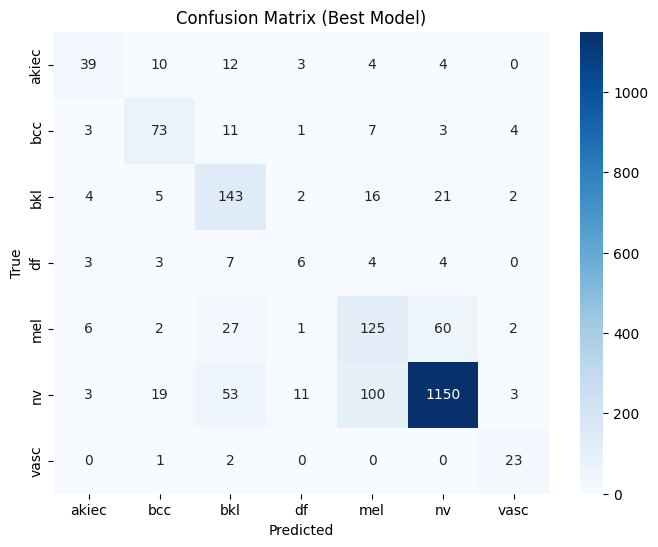

              precision    recall  f1-score   support

       akiec      0.672     0.542     0.600        72
         bcc      0.646     0.716     0.679       102
         bkl      0.561     0.741     0.638       193
          df      0.250     0.222     0.235        27
         mel      0.488     0.561     0.522       223
          nv      0.926     0.859     0.891      1339
        vasc      0.676     0.885     0.767        26

    accuracy                          0.787      1982
   macro avg      0.603     0.646     0.619      1982
weighted avg      0.805     0.787     0.793      1982



In [18]:
checkpoint = torch.load(CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}, F1: {checkpoint['val_f1']:.4f}")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        images = (images - MEAN) / STD
        with torch.cuda.amp.autocast():
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = sorted(label_map, key=label_map.get)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Best Model)')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))